In [ ]:
# Standard libraries
import os

# Scientific computing
import numpy as np
import pandas as pd

# Geospatial & Earth science data
import geopandas as gpd
import rioxarray
import xarray as xr

# Plotting & visualization
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
#import cmocean.cm as cmo

# Cartopy for geographic plotting
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader

# Scientific interpolation
from scipy.interpolate import RegularGridInterpolator, griddata

In [ ]:
logo_path      = '/mnt/dataset/01_ANALISA/00_Developing_Climate_Visualization/01.Anomali_Temperature_Monthly/data/logo.png'
scale_path     = '/mnt/dataset/01_ANALISA/00_Developing_Climate_Visualization/01.Anomali_Temperature_Monthly/data/scale.png'
arahangin_path = '/mnt/dataset/01_ANALISA/00_Developing_Climate_Visualization/01.Anomali_Temperature_Monthly/data/ArahAngin.png'

In [ ]:
spslPath  = '/mnt/dataset/00_DATA_SPASIAL'
INDO_path = os.path.join(spslPath,'Batas_Indonesia_38','idprov_38.shp')
LUAR_path = os.path.join(spslPath,'Batas_LN','luar_indo_lgkp.shp')
LAUT_path = os.path.join(spslPath,'Batas_Laut','Garis Pantai 50K (Garis) 2021.shp')
TLS_path  = os.path.join(spslPath,'Batas_Negara_Tetangga','BatasDarat_RI_RDTL.shp')
MLY_path  = os.path.join(spslPath,'Batas_Negara_Tetangga','BatasDarat_RIMalaysia.shp')
PNG_path  = os.path.join(spslPath,'Batas_Negara_Tetangga','BatasDarat_RI_PNG.shp')

INDO      = ShapelyFeature(Reader(INDO_path).geometries(), ccrs.PlateCarree())
PANTAI    = ShapelyFeature(Reader(LAUT_path).geometries(), ccrs.PlateCarree())
LN        = ShapelyFeature(Reader(LUAR_path).geometries(), ccrs.PlateCarree())

#INDO      = gpd.read_file(INDO_path)
TL        = gpd.read_file(TLS_path)
ML        = gpd.read_file(MLY_path)
PNG       = gpd.read_file(PNG_path)

for shp in [PNG, TL, ML]:
    if shp.crs != "EPSG:4326":
        shp.to_crs("EPSG:4326", inplace=True)

In [ ]:
url  = '/mnt/dataset/01_ANALISA/00_Developing_Climate_Visualization/01.Anomali_Temperature_Monthly/data/indo_basemap.nc'
ds   = xr.open_dataset(url)
topo = ds['ROSE']  # Data 2D: (lat, lon)
lons = ds['ETOPO05_X']
lats = ds['ETOPO05_Y']

# Konversi ke array numpy (opsional, tapi aman)
topo = topo.values
lons = lons.values
lats = lats.values

data_vars    = {'topo': (['lat', 'lon'], topo)}
coords       = {'lat': lats,'lon': lons}
batimetri_dt = xr.Dataset(data_vars, coords=coords)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs  # ← tambahkan ini

# Fungsi formatter untuk garis lintang (parallels)
def deg_to_degmin_lat(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk lintang."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    
    if deg == 0:
        sign = '0"'
        return f"{deg}°{minute:02d}'"  # Tanpa arah jika derajat = 0
    else:
        sign = '0"S' if is_neg else '0"N'
        return f"{deg}°{minute:01d}'{sign}"

# Fungsi formatter untuk garis bujur (meridians)
def deg_to_degmin_lon(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk bujur."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    sign = '0"W' if is_neg else '0"E'
    return f"{deg}°{minute:01d}'{sign}"

def format_axes(fig):
    for ax in fig.axes:
        ax.tick_params(labelbottom=False, labelleft=False)

def create_layout():
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.2)  # tambahkan jarak agar tidak tumpang tindih
    # Baris 0: satu subplot memanjang (2 kolom penuh)
    ax1 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
    # Baris 1: tiga subplot di kolom 0, 1, 2
    ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())  # kiri
    ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())  # tengah
    ax4 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())  # kanan
    format_axes(fig)
    return fig, ax1, ax2, ax3, ax4

# Plot Batasa Negara
def plot_shape_boundary(shape,ax, color='#599ae2', linewidth=0.5, linestyle='--', zorder=2, alpha=1):
    for _, row in shape.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            x, y = geom.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                        transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)

import matplotlib.colors as mcolors
def create_custom_colormap(color1="#ffffff", color2="#1eafe8", n_colors=200):
    start_rgb = np.array(mcolors.hex2color(color1))  # end_rgb
    end_rgb   = np.array(mcolors.hex2color(color2))  # start_rgb (logikanya disesuaikan)
    colors = []
    for i in range(n_colors):
        ratio = i / (n_colors - 1)
        rgb = start_rgb * (1 - ratio) + end_rgb * ratio
        hex_color = f"#{int(rgb[0]*255):02x}{int(rgb[1]*255):02x}{int(rgb[2]*255):02x}"
        colors.append(hex_color)

    cmap = mcolors.ListedColormap(colors)
    return cmap

import matplotlib.patches as mpatches
import math
def add_scale_bar_boxes(ax, length_km, location=(0.05, 0.05), n_segments=8, color='black', fontsize=8, linewidth=1):
    """
    Scale bar gaya kotak hitam-putih bergantian.
    """
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    center_lat = (y0 + y1) / 2
    km_per_deg_lon = 111.32 * math.cos(math.radians(center_lat))
    length_deg = length_km / km_per_deg_lon

    pos_x = x0 + location[0] * (x1 - x0)
    pos_y = y0 + location[1] * (y1 - y0)
    segment_length = length_deg / n_segments
    segment_height = 0.25

    for i in range(n_segments):
        x_start = pos_x + i * segment_length
        facecolor = 'black' if i % 2 == 0 else 'white'
        rect = mpatches.Rectangle(
            (x_start, pos_y),
            segment_length,
            segment_height,
            linewidth=linewidth,
            edgecolor=color,
            facecolor=facecolor,
            transform=ax.projection,
            zorder=10
        )
        ax.add_patch(rect)

    # Label "0"
    ax.text(pos_x, pos_y - 0.3, '0', ha='center', va='top', fontsize=fontsize, color=color, transform=ax.projection, zorder=10)
    # Label akhir
    ax.text(pos_x + length_deg, pos_y - 0.3, str(length_km), ha='center', va='top', fontsize=fontsize, color=color, transform=ax.projection, zorder=10)
    # Satuan
    ax.text(pos_x + length_deg + 0.05, pos_y - 0.3, '   km', ha='left', va='top', fontsize=fontsize, color=color, transform=ax.projection, zorder=10)


from matplotlib.patches import Rectangle
def custom_cbar(ax, levels, cmap, norm, n_cols=3, fontsize=8, box_size=0.09):
    colors = [cmap(norm(level)) for level in levels[:-1]]
    def format_val(v):
        return f"({v:.1f})" if v < 0 else f"{v:.1f}"

    labels = []
    for i in range(len(levels) - 1):
        if i == 0:
            labels.append(f"< {format_val(levels[1])}")
        elif i == len(levels) - 2:
            labels.append(f"> {format_val(levels[-2])}")
        else:
            labels.append(f"{format_val(levels[i])} – {format_val(levels[i+1])}")
            
    # Jangan gunakan ax.set_xlim(0, 1) atau ax.set_ylim(0, 1)
    # Karena ini akan mengganti koordinat dari add_axes
    ax.set_axis_off()
    n_items = len(colors)
    n_rows  = (n_items + n_cols - 1) // n_cols
    # Gunakan koordinat relatif terhadap ukuran sumbu
    x_start = 0.1  # 3% dari lebar sumbu
    y_start = 0.75  # 95% dari tinggi sumbu (dekat atas)
    dy  = 0.125 
    #dy = 0.1 if n_rows <= 2 else 0.15  # tinggi antar baris
    dx  = 0.4 if n_cols >= 3 else 0.5   # lebar antar kolom
    for i, (color, label) in enumerate(zip(colors, labels)):
        col = i // n_rows
        row = i % n_rows
        x = x_start + col * dx
        y = y_start - row * dy
        rect = Rectangle((x, y), box_size, box_size, facecolor=color, edgecolor='none', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(x + box_size + 0.04, y + box_size/2, label, va='center', ha='left', fontsize=fontsize)

def custom_cbar2(ax, levels, cmap, norm, n_cols=4, fontsize=8, box_size=0.09):
    colors = [cmap(norm(level)) for level in levels[:-1]]
    def format_val(v):
        return f"({v:.1f})" if v < 0 else f"{v:.1f}"

    labels = []
    for i in range(len(levels) - 1):
        if i == 0:
            labels.append(f"< {format_val(levels[1])}")
        elif i == len(levels) - 2:
            labels.append(f"> {format_val(levels[-2])}")
        else:
            labels.append(f"{format_val(levels[i])} – {format_val(levels[i+1])}")
            
    # Jangan gunakan ax.set_xlim(0, 1) atau ax.set_ylim(0, 1)
    # Karena ini akan mengganti koordinat dari add_axes
    ax.set_axis_off()
    n_items = len(colors)
    n_rows  = (n_items + n_cols - 1) // n_cols
    # Gunakan koordinat relatif terhadap ukuran sumbu
    x_start = 0.1  # 3% dari lebar sumbu
    y_start = 0.75  # 95% dari tinggi sumbu (dekat atas)
    dy      = 0.125 if n_rows >= 3 else 0.15  # tinggi antar baris
    dx      = 0.3 if n_cols >= 3 else 0.4   # lebar antar kolom
    for i, (color, label) in enumerate(zip(colors, labels)):
        col = i // n_rows
        row = i % n_rows
        x = x_start + col * dx
        y = y_start - row * dy
        rect = Rectangle((x, y), box_size, box_size, facecolor=color, edgecolor='none', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(x + box_size + 0.01, y + box_size/2, label, va='center', ha='left', fontsize=fontsize)

def create_categorical_colorbar(ax, colors, labels, fontsize=8, box_size=0.09, n_cols=3):
    ax.set_axis_off()
    n_items = len(colors)
    n_rows = (n_items + n_cols - 1) // n_cols

    x_start = 0.1
    y_start = 0.75
    dy = 0.125
    dx = 0.4 if n_cols >= 3 else 0.5

    for i, (color, label) in enumerate(zip(colors, labels)):
        col = i // n_rows
        row = i % n_rows
        x = x_start + col * dx
        y = y_start - row * dy

        rect = Rectangle((x, y), box_size, box_size, facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(x + box_size + 0.01, y + box_size/2, label, va='center', ha='left', fontsize=fontsize)

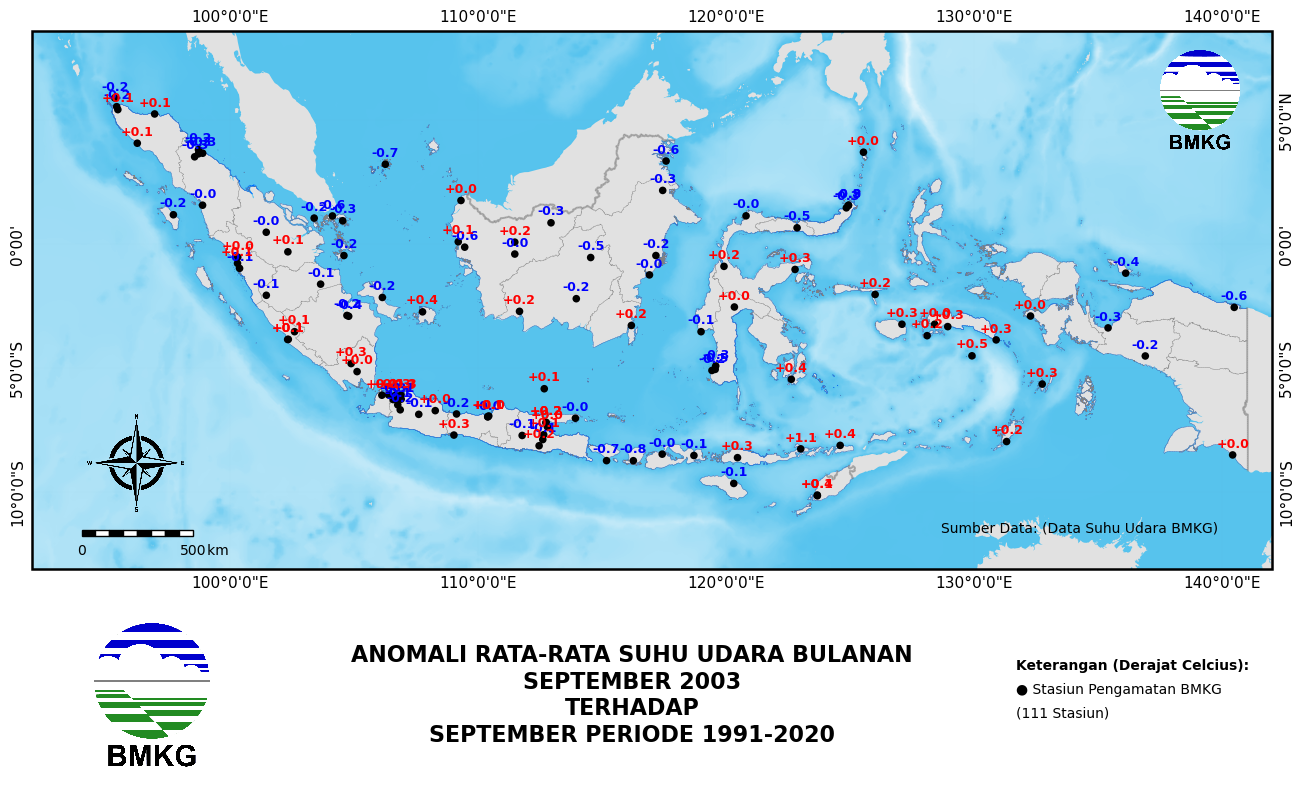

In [88]:
point_df      = pd.read_csv("/mnt/dataset/02_REPO_GITHUB_FIRMAN/Developing_Climate_Observation_Dataset/data/05.Long_Format_Dataset/06.TEMPERATURE_ANOMALI_DB.csv")
def plot_anomali_suhu(point_df, year, month):
    point_df_now  = point_df[(point_df['year'] == year) & (point_df['month'] == month)]
    point_df_now  = point_df_now.dropna(subset=['anomali'])
    total_stasiun = point_df_now['anomali'].reset_index(drop=True)
    bulan_full_name = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni',
                    7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}
    point_df_now['month_name'] = point_df_now['month'].map(bulan_full_name)
    bulan_now = point_df_now['month_name'].iloc[0].upper()
    year_now  = point_df_now['year'].iloc[0]

    # SETTING FONT ARIAL
    plt.rcParams.update({'font.size': 16, 'font.family': 'sans-serif'})
    plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial'] # Specify preferred fonts

    fig = plt.figure(figsize=(16, 10))
    ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([92, 142, -12, 8])
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    fig.patch.set_edgecolor('none')
    fig.patch.set_linewidth(3)
    gl              = ax.gridlines(draw_labels=True, linewidth=0.01, color='gray', alpha=0.7, linestyle='--')
    gl.xlocator     = mticker.FixedLocator(range(90, 150, 10))
    gl.ylocator     = mticker.FixedLocator(range(-15, 12, 5))
    gl.xformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lon(x))
    gl.yformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lat(x))
    gl.xlabel_style = {'rotation':0,'color': 'black', 'size': 11}
    gl.ylabel_style = {'rotation': 90, 'color': 'black', 'size': 11}

    # Ploting atribut peta
    custom_cmap = create_custom_colormap()
    batimetry   = ax.contourf(lons, lats, topo, levels=200, cmap=custom_cmap, transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#e1e1e1',zorder=2)
    plot_shape_boundary(PNG,ax=ax, linewidth=1.5, linestyle='solid', color='#808080', alpha=0.5,zorder=8)
    plot_shape_boundary(TL,ax=ax, linewidth=1.5,  linestyle='solid', color='#808080', alpha=0.5,zorder=8)
    plot_shape_boundary(ML,ax=ax, linewidth=1.5,  linestyle='solid', color='#808080', alpha=0.5,zorder=8)
    ax.add_feature(INDO, facecolor='none', edgecolor='grey', linewidth=0.25, zorder=9, linestyle='--')
    ax.add_feature(PANTAI, facecolor='none', edgecolor='#006eff', linewidth=0.25, zorder=6, linestyle='solid')

    # Menambahkan logo atas
    logo     = plt.imread(logo_path)
    imagebox = OffsetImage(logo, zoom=0.045)
    ab       = AnnotationBbox(
        imagebox, (0.91, 0.78),  # 2% from bottom-left corner
        xycoords='axes fraction',
        frameon=False,
        pad=0.0,
        box_alignment=(0, 0),
        zorder=10)
    ax.add_artist(ab)

    # Menambahkan arah angin
    angin    = plt.imread(arahangin_path)
    anginbox = OffsetImage(angin, zoom=0.1)
    ag = AnnotationBbox(
        anginbox, (0.03, 0.08),  # 2% from bottom-left corner
        xycoords='axes fraction',
        frameon=False,
        pad=0.0,
        box_alignment=(0, 0),
        zorder=11)
    ax.add_artist(ag)

    # PLOTING POINT DATA
    LAT_col = 'latitude'
    LON_col = 'longitude'
    VAL_col = 'anomali'
    # ================================
    # 1. PLOT TITIK STASIUN (DOT HITAM)
    # ================================
    ax.scatter(
        point_df_now['longitude'],
        point_df_now['latitude'],
        s=30,                    # ukuran titik
        color='black',           # semua titik hitam
        marker='o',
        edgecolor='none',        # tanpa border
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    # ================================
    # 2. TAMBAHKAN LABEL NILAI (WARNA SESUAI NILAI)
    # ================================
    for idx, row in point_df_now.iterrows():
        val = row['anomali']
        # Tentukan warna label
        label_color = 'red' if val > 0 else 'blue'
        # Format nilai: 1 desimal, tampilkan + untuk positif
        label_text = f"{val:+.1f}"  # contoh: +0.3, -0.2
        # Tambahkan teks di atas titik
        ax.text(
            row['longitude'],
            row['latitude'] + 0.2,  # sedikit di atas titik
            label_text,
            fontsize=9,
            fontweight='bold',
            color=label_color,
            ha='center',
            va='bottom',
            transform=ccrs.PlateCarree(),
            zorder=12
        )

    # ax.add_artist(sc)
    add_scale_bar_boxes(ax, length_km=500, location=(0.04, 0.06), color='black', fontsize=10)
    plt.figtext(0.78, 0.26, "Sumber Data: (Data Suhu Udara BMKG)", ha='center', va='bottom', fontsize=10, fontweight='medium')

    # KOTAK TAMBAHAN JML STASIUN
    ax_footer_left = fig.add_axes([0.725, 0.01, 0.15, 0.16])  # x, y, width, height
    ax_footer_left.text(0.1, 0.75, "Keterangan (Derajat Celcius):", transform=ax_footer_left.transAxes,ha='left', va='center', fontsize=10, fontweight='bold')
    ax_footer_left.text(0.1, 0.6, "● Stasiun Pengamatan BMKG", transform=ax_footer_left.transAxes,ha='left', va='center', fontsize=10)
    ax_footer_left.text(0.1, 0.45, f"({total_stasiun.count()} Stasiun)", transform=ax_footer_left.transAxes,ha='left', va='center', fontsize=10)
    ax_footer_left.set_facecolor('none')
    ax_footer_left.set_xticks([])
    ax_footer_left.set_yticks([])
    for spine in ax_footer_left.spines.values():
        spine.set_color('none')

    # KOTAK TAMBAHAN JUDUL
    ax_footer_center = fig.add_axes([0.30, 0.05, 0.40, 0.10])
    ax_footer_center.text(0.5, 0.5, f'ANOMALI RATA-RATA SUHU UDARA BULANAN\n{bulan_now} {year_now}\nTERHADAP\n{bulan_now} PERIODE 1991-2020', transform=ax_footer_center.transAxes,
                        ha='center', va='center', fontsize=18, fontweight='bold')
    ax_footer_center.set_facecolor('white')
    ax_footer_center.set_xticks([])
    ax_footer_center.set_yticks([])
    for spine in ax_footer_center.spines.values():
        spine.set_color('none')
        spine.set_linewidth(0.8)

    # KOTAK LOGO
    ax_footer_left = fig.add_axes([0.15, 0.05, 0.10, 0.10])
    ax_footer_left.set_xticks([])
    ax_footer_left.set_yticks([])
    logo_small = plt.imread(logo_path)
    imagebox_logo_small = OffsetImage(logo_small, zoom=0.065)
    ab_logo_small = AnnotationBbox(
        imagebox_logo_small,
        (0.5, 0.5),  # posisi tengah dalam axes
        xycoords='data',
        frameon=False,
        pad=0.1,      # <-- INI PADDING EKSTERNAL (jarak dari border axes)
        box_alignment=(0.5, 0.5),
        zorder=10)
    ax_footer_left.add_artist(ab_logo_small)
    for spine in ax_footer_left.spines.values():
        spine.set_color('none')
        spine.set_linewidth(0.8)

    outpath = '/mnt/dataset/02_REPO_GITHUB_FIRMAN/Developing_Climate_Observation_Dataset/data/05.Long_Format_Dataset/ANOMALI'
    os.makedirs(outpath, exist_ok=True)
    outfile = os.path.join(outpath, f'ANOMALI_TEMPERATURE_BULANAN_{year_now}_{bulan_now}.png')
    plt.savefig(outfile, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f'saved to :', outfile)
    plt.close()

import datetime
now     = datetime.datetime.now()
yearnow = now.year
for year in range(1991, yearnow + 1):
    for month in range(1, 13):
        try:
            plot_anomali_suhu(point_df, year, month)
        except Exception as e:
            print(f"Data tidak tersedia untuk {year}-{month:02d}")